# SVT Analysis
Notebook for quick SVT experiments and visualization.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
import numpy as np

PROJECT_ROOT = Path.cwd().parent
IMAGE_PATH = Path(PROJECT_ROOT) / "data" / "CBSD68"
NETFLIX_PATH = Path(PROJECT_ROOT) / "data" / "netflix"
RESULTS_PATH = Path(PROJECT_ROOT) / "results" / "svt" / "images"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.svt.svt import svt
from src.utils.masking import create_mask, apply_mask
from src.utils.noise import add_gaussian_noise
from src.utils.io import load_image
from src.utils.metrics import mse, nmse, psnr

from experiments.config import *

In [ ]:
rec = pd.read_csv(RESULTS_PATH / "reconstruction.csv")
den = pd.read_csv(RESULTS_PATH / "denoising.csv")

rec_avg = rec.groupby("sparsity")["PSNR"].mean()
den_avg = den.groupby("sigma")["PSNR"].mean()

print("Reconstruction PSNR vs. Observed Fraction:", rec_avg)
print("Denoising PSNR vs. Noise Level:", den_avg)

Reconstruction PSNR vs. Observed Fraction: sparsity
0.2    19.965647
0.4    21.833601
0.6    22.009868
Name: PSNR, dtype: float64
Denoising PSNR vs. Noise Level: sigma
0.05    22.078218
0.10    21.912195
0.20    20.858750
Name: PSNR, dtype: float64


In [87]:
def show_results(X, X_rec, X_noisy=None, X_masked=None, title=""):
    plt.figure(figsize=(12, 4))

    if X_noisy is not None:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap="gray", vmin=0, vmax=1)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_noisy, cmap='gray', vmin=0, vmax=1)
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap="gray", vmin=0, vmax=1)
        plt.title("Denoised")
        plt.axis("off")

    else:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap='gray', vmin=0, vmax=255)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_masked, cmap='gray', vmin=0, vmax=255)
        plt.title("Observed pixels")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap='gray', vmin=0, vmax=255)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

In [88]:
# Reconstruction
X = load_image(IMAGE_PATH / "0047.png")
X = X[:256, :256]
print(X.min(), X.max(), X.dtype)

n1, n2 = X.shape
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction

tau = 8 * max(n1, n2) # tau = 8 * 256 = 2048  -> try 6, 7, 8  for tau factor?
# print(np.mean(X))
delta = DELTA_FACTOR / observed_fraction # delta = 1.2 / 0.8 = 1.5

mask = create_mask(X.shape, observed_fraction, seed=SEED)
Omega, b = apply_mask(X, mask)

X_masked = np.zeros_like(X)
X_masked[Omega] = b

38.0 195.0 float64


NMSE: 0.004886716818213309
PSNR: 23.10982827301006


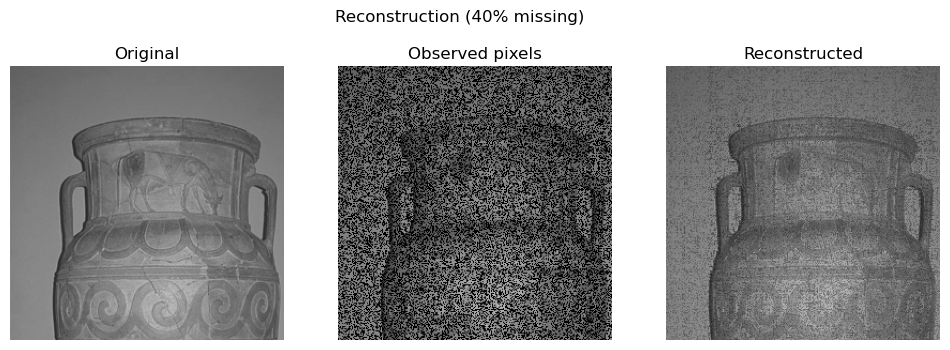

In [89]:
X_rec, hist = svt(X.shape, Omega, b, tau, delta)
# X_rec = np.clip(X_rec, 0, 1)

print("NMSE:", nmse(X, X_rec, data_range=255))
print("PSNR:", psnr(X, X_rec, data_range=255))

show_results(X, X_rec, X_masked=X_masked, title=f"Reconstruction ({missing_fraction*100:.0f}% missing)")

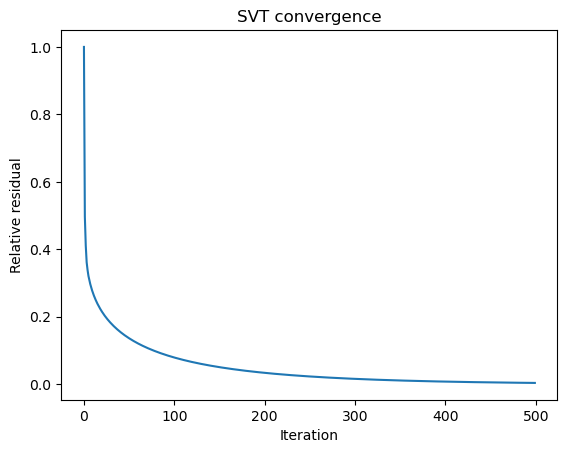

In [ ]:
# Check if the residual decreases monotonically
plt.plot(hist["residual"])
plt.title("SVT convergence")
plt.xlabel("Iteration")
plt.ylabel("Relative residual")
plt.show()

Text(0.5, 1.0, 'Image singular value decay')

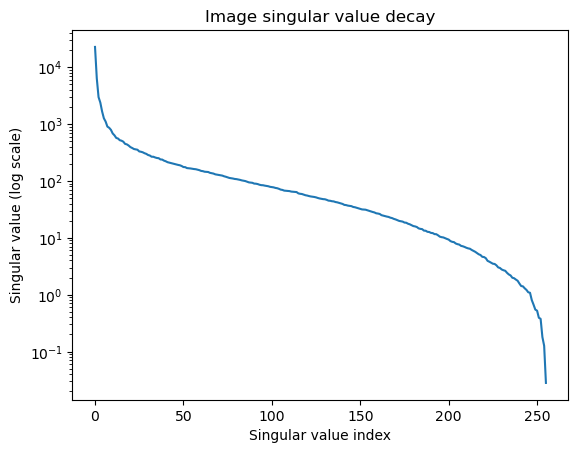

In [94]:
# Check if the singular values decay rapidly
U, S, Vt = np.linalg.svd(X, full_matrices=False)
plt.semilogy(S)
plt.xlabel("Singular value index")
plt.ylabel("Singular value (log scale)")
plt.title("Image singular value decay")

NMSE: 0.006589254278384811
PSNR: 21.81163732766837


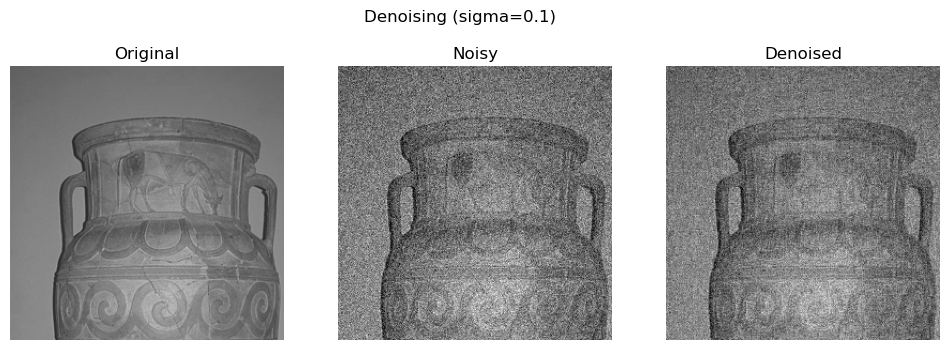

In [57]:
# Denoising
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

# sigma = 0.1 * 255  # sigma = 0.1 * 255 = 25.5
sigma = 0.1  # sigma = 0.1 in [0,1] range
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)

n1, n2 = X.shape
# tau = 2 * sigma * max(n1, n2)
tau = TAU_FACTOR * max(n1, n2) # tau = 5 * 256 = 1536
delta = DELTA_FACTOR

Omega = np.where(np.ones_like(X, dtype=bool))
b = X_noisy[Omega]

X_denoised, _ = svt(X.shape, Omega, b, tau, delta)
    
print("NMSE:", nmse(X, X_denoised, data_range=1.0))
print("PSNR:", psnr(X, X_denoised, data_range=1.0))

show_results(X, X_denoised, X_noisy=X_noisy, title="Denoising (sigma=0.1)")

## Patch-based SVT

### Image Reconstruction

In [81]:
# Overlapping patch extraction and reconstruction
def extract_patches(X, patch_size, stride):

    patches = []
    positions = []

    h, w = X.shape

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):

            patch = X[i:i+patch_size, j:j+patch_size]

            patches.append(patch)
            positions.append((i, j))

    return patches, positions

def reconstruct_from_patches(patches, positions, image_shape, patch_size):

    X = np.zeros(image_shape)
    weight = np.zeros(image_shape)

    for patch, (i, j) in zip(patches, positions):

        X[i:i+patch_size, j:j+patch_size] += patch
        weight[i:i+patch_size, j:j+patch_size] += 1

    return X / weight

def svt_patch_completion(X, mask, patch_size=32, stride=16):

    patches, positions = extract_patches(X, patch_size, stride)
    mask_patches, _ = extract_patches(mask.astype(float), patch_size, stride)

    rec_patches = []

    for patch, patch_mask in zip(patches, mask_patches):

        Omega = np.where(patch_mask)
        b = patch[Omega]

        tau = TAU_FACTOR * patch_size
        delta = 1.2

        X_rec, _ = svt(patch.shape, Omega, b, tau, delta)

        rec_patches.append(X_rec)

    return reconstruct_from_patches(
        rec_patches,

        positions,
        X.shape,
        patch_size
    )

In [82]:
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

n1, n2 = X.shape
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction

mask = create_mask(X.shape, observed_fraction, seed=SEED)

X_masked = np.zeros_like(X)
X_masked[mask] = X[mask]

X_rec = svt_patch_completion(X, mask)

NMSE: 0.0005548835590847875
PSNR: 32.55798142917918


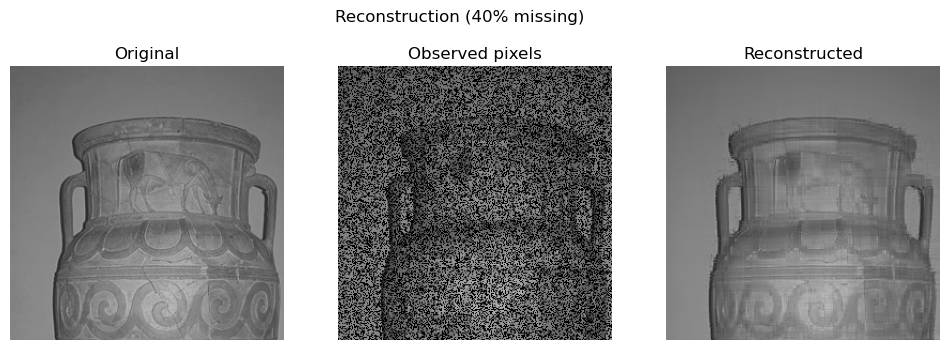

In [83]:
print("NMSE:", nmse(X, X_rec, data_range=1.0))
print("PSNR:", psnr(X, X_rec, data_range=1.0))

show_results(X, X_rec, X_masked=X_masked, title=f"Reconstruction ({missing_fraction*100:.0f}% missing)")

### Image Denoising

In [90]:
def svt_patch_denoising(X_noisy, patch_size=32, stride=16, tau_factor=TAU_FACTOR, delta=DELTA_FACTOR):
    patches, positions = extract_patches(X_noisy, patch_size, stride)

    denoised_patches = []

    for patch in patches:
        # For denoising, every pixel is observed in each noisy patch.
        Omega = np.where(np.ones_like(patch, dtype=bool))
        b = patch[Omega]

        tau = tau_factor * patch_size
        X_patch_denoised, _ = svt(patch.shape, Omega, b, tau, delta)

        denoised_patches.append(X_patch_denoised)

    return reconstruct_from_patches(
        denoised_patches,
        positions,
        X_noisy.shape,
        patch_size
    )

X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

sigma = 0.1
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)

X_denoised_patch = svt_patch_denoising(
    X_noisy,
    patch_size=32,
    stride=16,
    tau_factor=TAU_FACTOR,
    delta=DELTA_FACTOR
)

Patch-SVT Denoising NMSE: 0.009613626927080761
Patch-SVT Denoising PSNR: 20.171127354062413


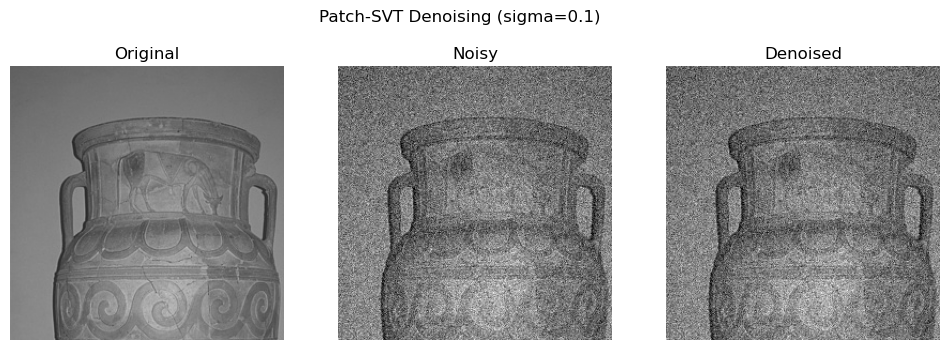

In [91]:
print("Patch-SVT Denoising NMSE:", nmse(X, X_denoised_patch, data_range=1.0))
print("Patch-SVT Denoising PSNR:", psnr(X, X_denoised_patch, data_range=1.0))

show_results(
    X,
    X_denoised_patch,
    X_noisy=X_noisy,
    title=f"Patch-SVT Denoising (sigma={sigma})"
)